In [1]:
import pandas as pd
import os
from pathlib import Path
import matplotlib.pyplot as plt
from matplotlib import colormaps
import geopandas as gpd
import numpy as np
import xarray as xr
import rioxarray as rxr
import codebase

Notes:
- Neches is a triburtary of Sabine river. Number of dams is one more than the number of basins.

In [2]:
grdc_dir = "/global/scratch/users/ann_scheliga/aux_dam_datasets/GRDC_CRB/"
res_dir = "/global/scratch/users/ann_scheliga/CYGNSS_daily/time_series/"

In [3]:
res_shp = codebase.load_data.load_GRanD()
subregions_meta = gpd.read_file(grdc_dir + 'subregions.geojson')

In [4]:
site_series = pd.read_json('../dam_basin_pair.json',typ='series')

In [5]:
site_stations = gpd.read_file(grdc_dir+'site_stationbasins.geojson')
site_stations.set_index(site_stations['grdc_no'].astype(int),inplace=True)

In [6]:
dam_names = [item.replace('_',' ') for item in list(site_series)]
dam_shps = res_shp[res_shp['DAM_NAME'].str.lower().isin(dam_names)]

## Create and write synthesized station basin dataset
from site_series variable (```dam_basin_pair.json``` file).

Only need to run when new basin-dam pairs added.

In [ ]:
# station_fn_list = [fn for fn in os.listdir(grdc_dir) if 'stationbasins' in fn]
# site_stations = gpd.GeoDataFrame()
# for fn in station_fn_list:
#     stations_meta = gpd.read_file(grdc_dir + fn)
#     stations_meta.set_index(stations_meta['grdc_no'].astype(int),inplace=True)
#     stations = stations_meta[stations_meta.index.isin(site_series.index)]
#     site_stations = pd.concat([site_stations, stations])
# site_stations.to_file(grdc_dir+'site_stationbasins.geojson',driver='GeoJSON',index=False)

## Create global map

In [7]:
world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))

/tmp/ipykernel_95693/3912264495.py:1: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))


In [8]:
site_stations['lat_lon'] = gpd.points_from_xy(y =site_stations['lat_org'], x =  site_stations['long_org'])
stations_points = site_stations.set_geometry('lat_lon', crs = "EPSG:4326")

In [9]:
cmap_colors = colormaps['tab20'].colors

basin_green = cmap_colors[5]
res_blue = cmap_colors[0]
station_orange = cmap_colors[6]

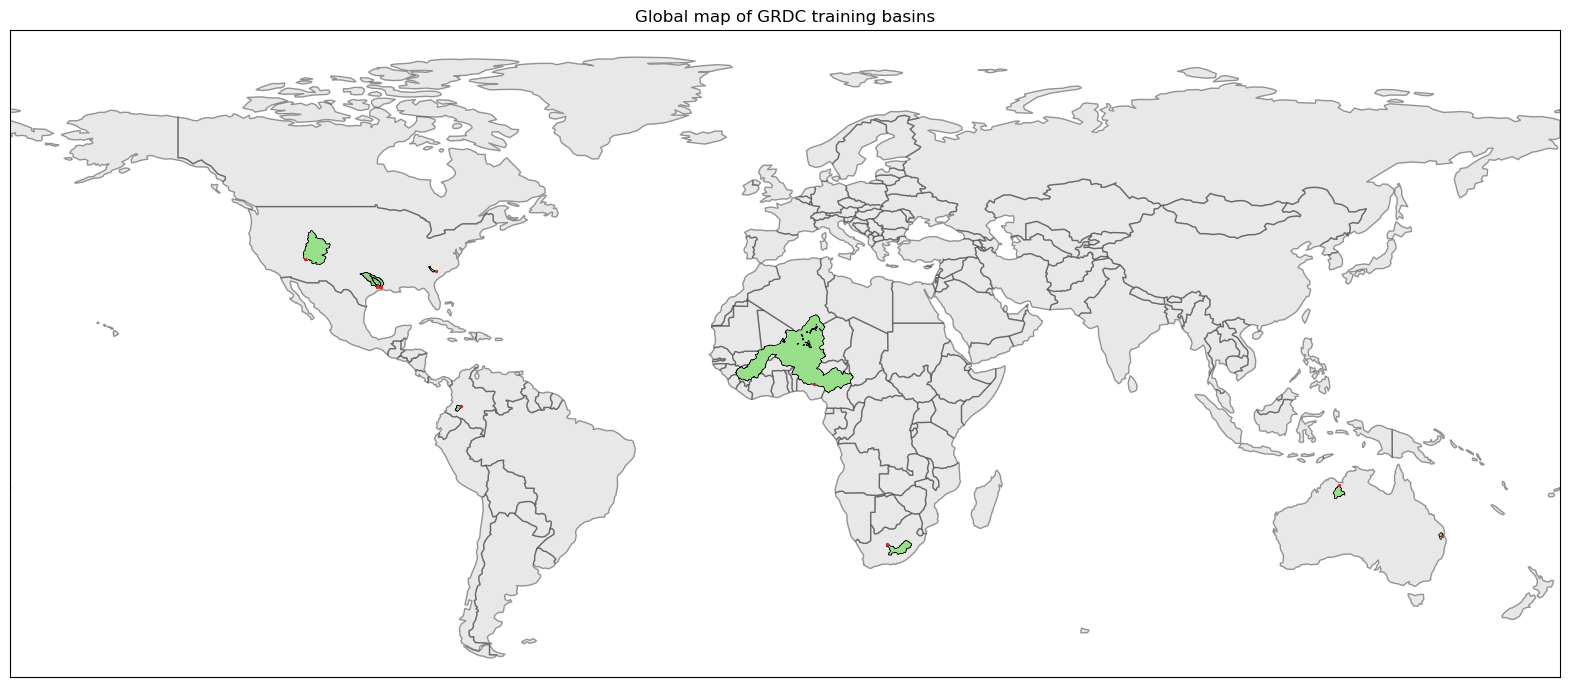

In [13]:
fig = plt.figure(figsize=(20, 10))
ax = fig.add_subplot()
lightblue = np.array([58,147,195])/255

# plot a basic map of the world
world.plot(
    ax = ax,
    color="lightgray",
    edgecolor=[0.2,0.2,0.2],
    alpha=0.5
)

# turn off axis ticks
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim([-180,180])
ax.set_ylim([-60,90])

site_stations.plot(ax=ax,color=basin_green,edgecolor='black',linewidth=0.4)
stations_points.plot(ax=ax,color=station_orange,edgecolor=station_orange,markersize=2)

# set the plot title
plt.title("Global map of GRDC training basins")
plt.savefig('./global_grdc_basin_map.png')